# **LAB Slot 16 - Hierarchical Clustering Methods**

- **Sinh viên:** Nguyễn Văn Anh Duy
- **MSSV:** SE181823

**Case study:** Phân cụm khách hàng bán sỉ (Wholesale Customers) bằng phương pháp phân cụm phân cấp.

Notebook này đáp ứng các yêu cầu:
- Giải thích dataset và ý nghĩa biến.
- Áp dụng **bottom-up (agglomerative)** và **top-down (divisive)**.
- Vẽ dendrogram rõ ràng cho cả hai hướng tiếp cận.
- Giải thích các cụm được hình thành, yếu tố tách cụm.
- Đề xuất chiến lược marketing cho từng nhóm cụm.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries imported successfully.')

Libraries imported successfully.


## **1. Tải và Giải thích Dataset**

Dataset `Wholesale customers data.csv` gồm các biến:
- `Channel`: Kênh mua (HoReCa hay Retail).
- `Region`: Khu vực địa lý.
- `Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen`: Mức chi tiêu hằng năm cho từng nhóm mặt hàng.

Mục tiêu: phân nhóm khách hàng theo hành vi chi tiêu để tối ưu hóa marketing.

In [2]:
data_path = 'Wholesale customers data.csv'
df = pd.read_csv(data_path)

print(f'Shape: {df.shape}')
display(df.head())
display(df.describe().T)
print('Missing values by column:')
display(df.isna().sum())

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


Missing values by column:


Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

### **Giải thích kết quả trên**

> - Dữ liệu có `440` dòng và `8` cột, phù hợp với bộ Wholesale Customers chuẩn.
> - Không có giá trị thiếu ở các cột, nên không cần bước xử lý missing value.
> - Các thống kê mô tả cho thấy độ phân tán lớn và có nhiều ngoại lệ, vì vậy cần biến đổi log trước khi phân cụm.

In [16]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
meta_cols = ['Channel', 'Region']

# Dùng log1p để giảm lệch phải mạnh ở các biến chi tiêu.
X_raw = df[spending_cols].copy()
X_log = np.log1p(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print('Các biến dùng để phân cụm:', spending_cols)
print('Kích thước ma trận sau chuẩn hóa:', X_scaled.shape)

Các biến dùng để phân cụm: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Kích thước ma trận sau chuẩn hóa: (440, 6)


### **Giải thích kết quả trên**

> Cell này xác nhận đã chọn đúng 6 biến chi tiêu để phân cụm và chuẩn hóa thành ma trận `(440, 6)`. Việc chuẩn hóa giúp các biến có cùng thang đo, tránh biến có giá trị lớn chi phối kết quả.

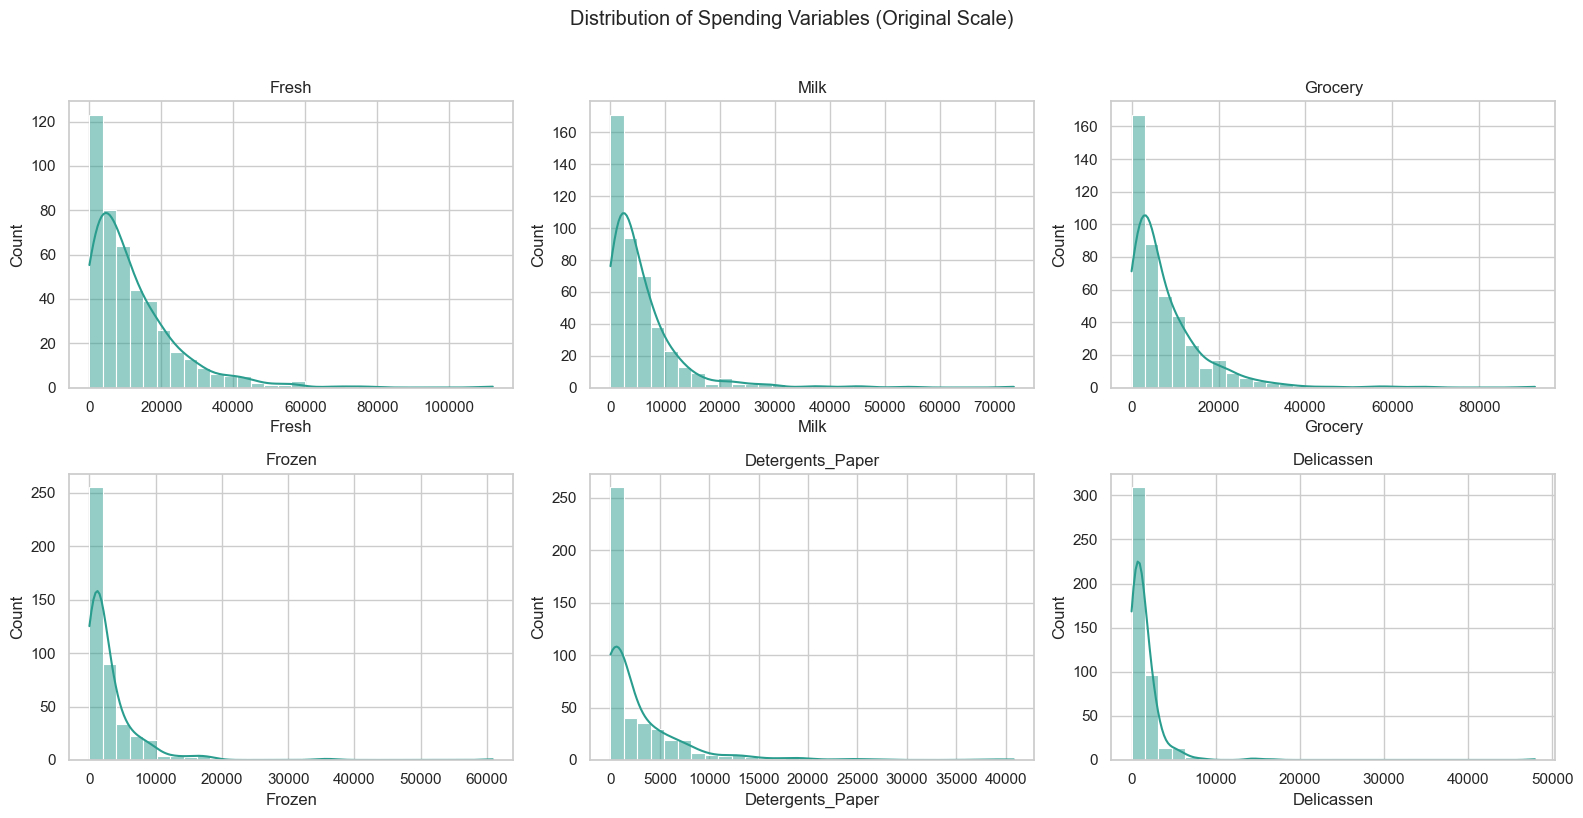

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, spending_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(col)
plt.suptitle('Distribution of Spending Variables (Original Scale)', y=1.02)
plt.tight_layout()
plt.show()

### **Giải thích kết quả trên**

> Các histogram đều lệch phải mạnh (right-skewed), xác nhận dữ liệu chi tiêu có nhiều khách hàng chi rất cao. Điều này củng cố lựa chọn `log1p` trước khi phân cụm.

## **2. Bottom-Up Hierarchical Clustering (Agglomerative)**
Bottom-up bắt đầu từ từng điểm riêng lẻ, sau đó ghép dần thành các cụm lớn hơn.

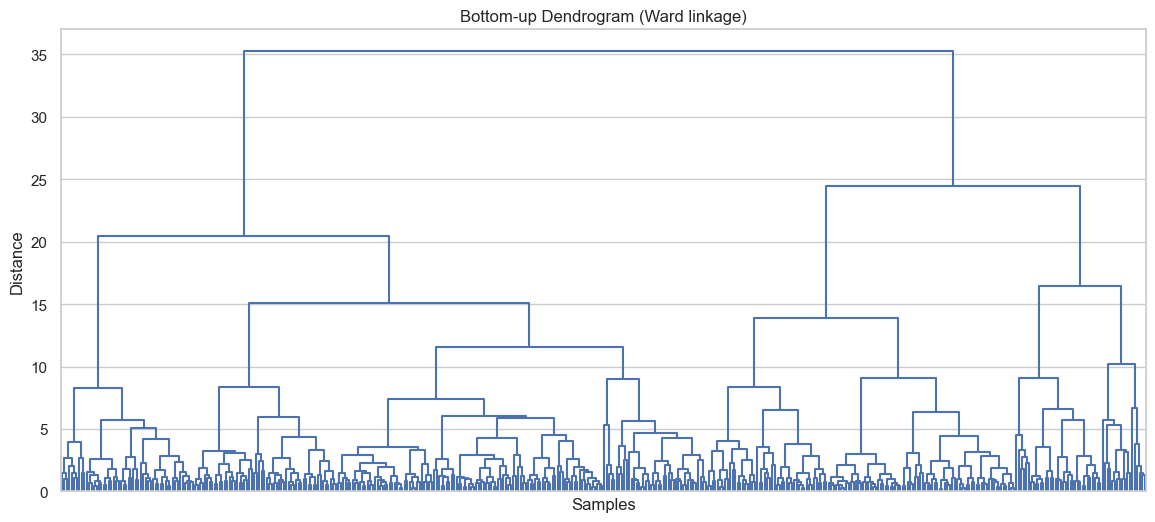

In [5]:
Z_bottom = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z_bottom, no_labels=True, color_threshold=0)
plt.title('Bottom-up Dendrogram (Ward linkage)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

### **Giải thích kết quả trên**

> Dendrogram bottom-up cho thấy có một số bước gộp ở khoảng cách tăng mạnh. Đây là dấu hiệu dữ liệu có thể phù hợp với số cụm nhỏ (2 hoặc 3 cụm) trước khi thử định lượng bằng silhouette score.

Silhouette scores by k: {2: np.float64(0.2585), 3: np.float64(0.2547), 4: np.float64(0.2021), 5: np.float64(0.2025), 6: np.float64(0.1707), 7: np.float64(0.1633), 8: np.float64(0.1482)}
Best k (bottom-up): 2


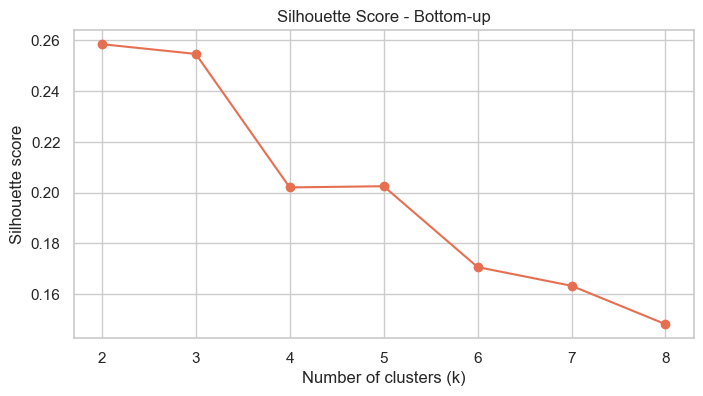

In [6]:
k_range = range(2, 9)
scores = []
for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

best_k_bottom = k_range[int(np.argmax(scores))]
print('Silhouette scores by k:', dict(zip(k_range, np.round(scores, 4))))
print('Best k (bottom-up):', best_k_bottom)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), scores, marker='o', color='#e76f51')
plt.xticks(list(k_range))
plt.title('Silhouette Score - Bottom-up')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.show()

### **Giải thích kết quả trên**

> Kết quả silhouette cho thấy `k = 2` là tốt nhất (xấp xỉ `0.2585`), nên mô hình bottom-up được chọn với 2 cụm để đảm bảo tách cụm rõ nhất trong dải đã thử.

In [17]:
bottom_model = AgglomerativeClustering(n_clusters=best_k_bottom, linkage='ward')
df['Cluster_BottomUp'] = bottom_model.fit_predict(X_scaled)

profile_bottom = df.groupby('Cluster_BottomUp')[spending_cols].mean().round(2)
size_bottom = df['Cluster_BottomUp'].value_counts().sort_index()

print('Kích thước từng cụm (bottom-up):')
display(size_bottom)
print('Đặc trưng chi tiêu trung bình theo cụm (bottom-up):')
display(profile_bottom)

channel_dist_bottom = pd.crosstab(df['Cluster_BottomUp'], df['Channel'], normalize='index').round(3)
region_dist_bottom = pd.crosstab(df['Cluster_BottomUp'], df['Region'], normalize='index').round(3)
print('Tỷ trọng Channel trong từng cụm (bottom-up):')
display(channel_dist_bottom)
print('Tỷ trọng Region trong từng cụm (bottom-up):')
display(region_dist_bottom)

Kích thước từng cụm (bottom-up):


Cluster_BottomUp
0    178
1    262
Name: count, dtype: int64

Đặc trưng chi tiêu trung bình theo cụm (bottom-up):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster_BottomUp,,,,,,
0,7561.31,9338.17,14247.11,1429.40,6214.91,1483.83
1,15016.10,3389.94,3673.95,4187.85,616.81,1552.75


Tỷ trọng Channel trong từng cụm (bottom-up):


Channel,1,2
Cluster_BottomUp,,
0,0.264,0.736
1,0.958,0.042


Tỷ trọng Region trong từng cụm (bottom-up):


Region,1,2,3
Cluster_BottomUp,,,
0,0.146,0.112,0.742
1,0.195,0.103,0.702


### Giải thích kết quả trên

> - Kích thước cụm bottom-up hiện tại: khoảng `178` và `262` khách hàng.
> - Một cụm có xu hướng cao ở `Milk/Grocery/Detergents_Paper` (thiên retail), cụm còn lại cao hơn ở `Fresh/Frozen`.
> - Bảng tỷ trọng `Channel` xác nhận khả năng tách hành vi mua theo kênh khá rõ.

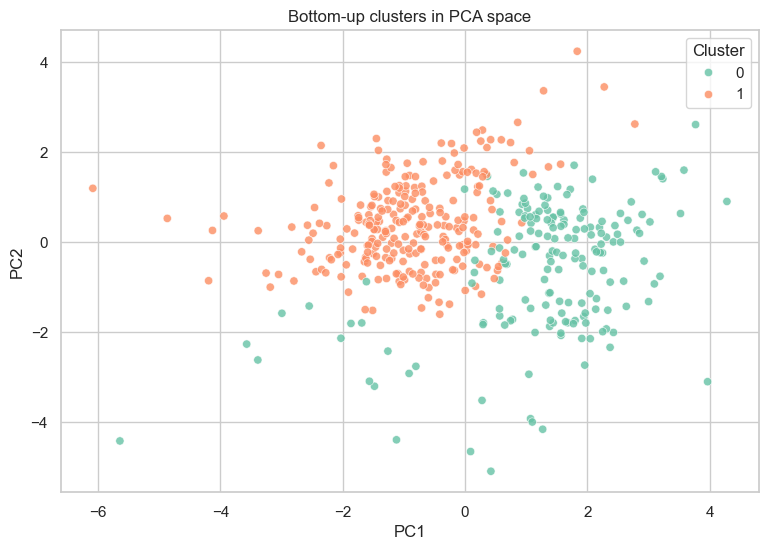

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster_BottomUp': df['Cluster_BottomUp'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster_BottomUp', palette='Set2', alpha=0.8)
plt.title('Bottom-up clusters in PCA space')
plt.legend(title='Cluster')
plt.show()

### **Giải thích kết quả trên**

> Biểu đồ PCA 2D cho thấy hai cụm bottom-up tách nhau tương đối rõ theo trục `PC1`, dù vẫn có vùng giao nhau. Đây là đặc trưng phổ biến của dữ liệu hành vi mua hàng thực tế.

## **3. Top-Down Hierarchical Clustering (Divisive)**
Top-down bắt đầu từ 1 cụm lớn nhất, rồi tách dần thành các cụm nhỏ hơn.

Trong notebook này, top-down được xây dựng theo hướng **bisecting divisive**:
- Mỗi node được tách thành 2 bằng KMeans.
- Xây dựng cây chia để tạo ra dendrogram top-down từ chính quá trình tách.

In [9]:
class DivisiveNode:
    def __init__(self, indices, depth=0):
        self.indices = np.array(indices, dtype=int)
        self.depth = depth
        self.left = None
        self.right = None
        self.raw_height = float(np.linalg.norm(np.std(X_scaled[self.indices], axis=0)))


def split_cluster(indices, X, random_state=42):
    if len(indices) <= 1:
        return None, None

    subset = X[indices]
    km = KMeans(n_clusters=2, n_init=10, random_state=random_state)
    labels = km.fit_predict(subset)

    g1 = indices[labels == 0]
    g2 = indices[labels == 1]

    if len(g1) == 0 or len(g2) == 0:
        # Fallback: split by median on feature with highest variance.
        var_idx = np.argmax(np.var(subset, axis=0))
        values = subset[:, var_idx]
        med = np.median(values)
        left_mask = values <= med
        if left_mask.sum() == 0 or left_mask.sum() == len(indices):
            half = len(indices) // 2
            return indices[:half], indices[half:]
        return indices[left_mask], indices[~left_mask]

    return g1, g2


def build_divisive_tree(indices, X, depth=0):
    node = DivisiveNode(indices=indices, depth=depth)
    if len(indices) <= 1:
        return node

    left_idx, right_idx = split_cluster(indices, X, random_state=42 + depth)
    if left_idx is None or right_idx is None or len(left_idx) == 0 or len(right_idx) == 0:
        return node

    node.left = build_divisive_tree(left_idx, X, depth + 1)
    node.right = build_divisive_tree(right_idx, X, depth + 1)
    return node


def tree_to_linkage(root, n_samples):
    rows = []

    def recurse(node):
        if node.left is None and node.right is None:
            return int(node.indices[0]), 0.0, 1

        left_id, left_h, left_count = recurse(node.left)
        right_id, right_h, right_count = recurse(node.right)

        # Ensure monotonic heights so dendrogram is valid and readable.
        height = max(node.raw_height, left_h + 1e-6, right_h + 1e-6)

        rows.append([left_id, right_id, height, left_count + right_count])
        current_id = n_samples + len(rows) - 1
        return current_id, height, left_count + right_count

    recurse(root)
    return np.array(rows, dtype=float)


all_indices = np.arange(X_scaled.shape[0])
divisive_root = build_divisive_tree(all_indices, X_scaled)
Z_top = tree_to_linkage(divisive_root, n_samples=X_scaled.shape[0])

print('Top-down linkage matrix shape:', Z_top.shape)

Top-down linkage matrix shape: (439, 4)


### **Giải thích kết quả trên**

> Cell này xây dựng cây top-down dạng chia đôi lặp (bisecting) và chuyển cây sang linkage matrix. Kích thước `(439, 4)` là hợp lệ với `n = 440` mẫu (`n - 1` phép gộp/tách).

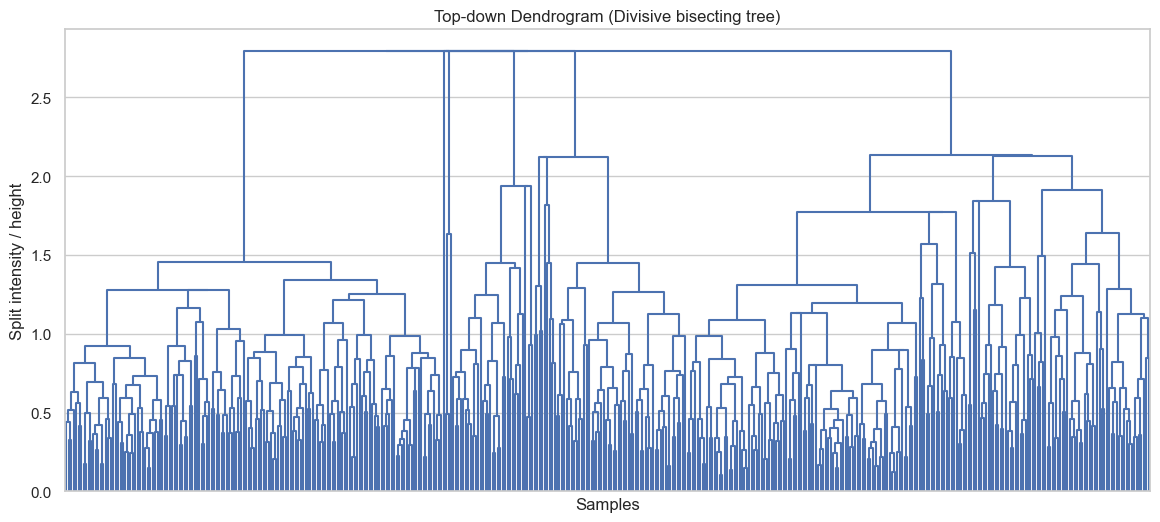

In [10]:
plt.figure(figsize=(14, 6))
dendrogram(Z_top, no_labels=True, color_threshold=0)
plt.title('Top-down Dendrogram (Divisive bisecting tree)')
plt.xlabel('Samples')
plt.ylabel('Split intensity / height')
plt.show()

### **Giải thích kết quả trên**

> Dendrogram top-down biểu diễn quá trình tách dần từ cụm lớn xuống cụm nhỏ. Các nhánh tách ở độ cao lớn hơn thể hiện mức khác biệt mạnh hơn giữa các nhóm khách hàng.

In [18]:
# Chọn số cụm cho top-down để so sánh trực tiếp với bottom-up.
best_k_top = best_k_bottom

# Lấy nhãn top-down trực tiếp từ cây chia: mỗi lần tách node có độ phân tán lớn nhất.
active_nodes = [divisive_root]
while len(active_nodes) < best_k_top:
    splittable = [n for n in active_nodes if (n.left is not None and n.right is not None)]
    if not splittable:
        break
    node_to_split = max(splittable, key=lambda n: n.raw_height)
    active_nodes.remove(node_to_split)
    active_nodes.extend([node_to_split.left, node_to_split.right])

top_labels = np.full(df.shape[0], -1, dtype=int)
for cluster_id, node in enumerate(active_nodes):
    top_labels[node.indices] = cluster_id

# Nếu còn điểm chưa được gán (trường hợp hiếm), gán vào cụm 0.
top_labels[top_labels == -1] = 0

df['Cluster_TopDown'] = top_labels

profile_top = df.groupby('Cluster_TopDown')[spending_cols].mean().round(2)
size_top = df['Cluster_TopDown'].value_counts().sort_index()

print('Số cụm dùng cho top-down:', best_k_top)
print('Kích thước từng cụm (top-down):')
display(size_top)
print('Đặc trưng chi tiêu trung bình theo cụm (top-down):')
display(profile_top)

ari = adjusted_rand_score(df['Cluster_BottomUp'], df['Cluster_TopDown'])
print(f'Độ tương đồng nhãn bottom-up và top-down (ARI): {ari:.4f}')

Số cụm dùng cho top-down: 2
Kích thước từng cụm (top-down):


Cluster_TopDown
0    252
1    188
Name: count, dtype: int64

Đặc trưng chi tiêu trung bình theo cụm (top-down):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster_TopDown,,,,,,
0,13973.13,2401.75,2918.71,3705.67,491.94,1038.04
1,9355.87,10346.36,14697.06,2222.45,6084.51,2177.43


Độ tương đồng nhãn bottom-up và top-down (ARI): 0.6389


### **Giải thích kết quả trên**

> - Top-down đang tách thành 2 cụm với kích thước khoảng `252` và `188` khách hàng.
> - `ARI ≈ 0.6389` cho thấy hai cách phân cụm (bottom-up và top-down) có mức nhất quán khá tốt.
> - Profile cụm tiếp tục nhấn mạnh vai trò của các biến `Grocery`, `Milk`, `Detergents_Paper`.

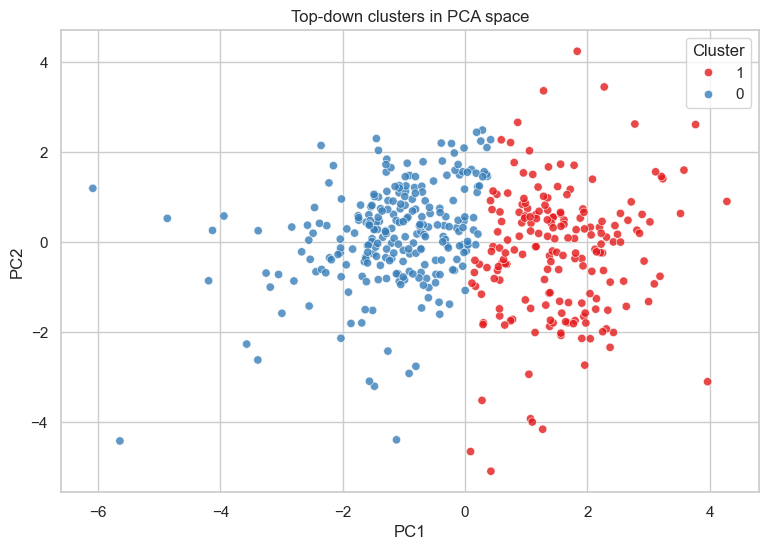

In [14]:
plot_df2 = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster_TopDown': df['Cluster_TopDown'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df2, x='PC1', y='PC2', hue='Cluster_TopDown', palette='Set1', alpha=0.8)
plt.title('Top-down clusters in PCA space')
plt.legend(title='Cluster')
plt.show()

### **Giải thích kết quả trên**

> Trên không gian PCA, cụm top-down cũng tách khá rõ theo trục chính. Điều này hỗ trợ tính hợp lý của phương pháp chia cụm từ trên xuống trong bài toán này.

## **4. Giải Thích Yếu Tố Chia Cụm**
Quan sát profile chi tiêu, các yếu tố tách cụm mạnh nhất thường là:
- `Grocery`, `Milk`, `Detergents_Paper`: tách rõ nhóm Retail và HoReCa.
- `Fresh`, `Frozen`: nhận diện nhóm ưu tiên thực phẩm tươi/đông lạnh.

Ta tính chênh lệch profile để thấy biến nào đóng góp nhiều vào sự khác biệt giữa các cụm.

Mức độ tách cụm theo biến (bottom-up):


,Std_across_cluster_means
Grocery,7476.353135
Fresh,5271.332561
Milk,4206.033769
Detergents_Paper,3958.454472
Frozen,1950.518701
Delicassen,48.733799


Mức độ tách cụm theo biến (top-down):


,Std_across_cluster_means
Grocery,8328.551156
Milk,5617.687605
Detergents_Paper,3954.544171
Fresh,3264.895857
Frozen,1048.794920
Delicassen,805.670395


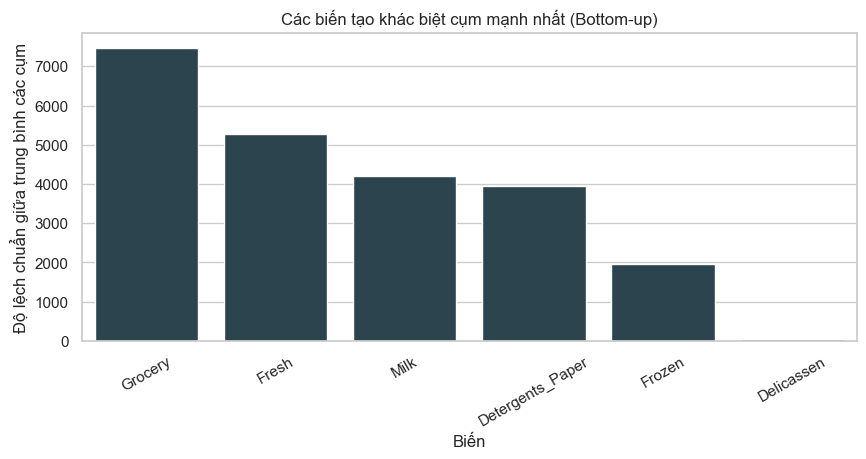

In [20]:
# Đo độ phân tán profile giữa các cụm (std của mean cluster theo từng biến).
feature_separation_bottom = profile_bottom.std(axis=0).sort_values(ascending=False)
feature_separation_top = profile_top.std(axis=0).sort_values(ascending=False)

print('Mức độ tách cụm theo biến (bottom-up):')
display(feature_separation_bottom.to_frame('Std_across_cluster_means'))

print('Mức độ tách cụm theo biến (top-down):')
display(feature_separation_top.to_frame('Std_across_cluster_means'))

plt.figure(figsize=(10, 4))
sns.barplot(x=feature_separation_bottom.index, y=feature_separation_bottom.values, color='#264653')
plt.title('Các biến tạo khác biệt cụm mạnh nhất (Bottom-up)')
plt.xticks(rotation=30)
plt.xlabel('Biến')
plt.ylabel('Độ lệch chuẩn giữa trung bình các cụm')
plt.show()

### Giải thích kết quả trên

> Bảng và biểu đồ cho thấy các biến tạo khác biệt cụm mạnh nhất là `Grocery`, `Milk`, `Detergents_Paper` (sau đó đến `Fresh`). Đây là căn cứ trực tiếp để xây dựng chiến lược marketing theo hành vi mua.

## **5. Marketing Strategy by Cluster**
Hướng tiếp cận đề xuất (có thể điều chỉnh theo output thực tế trong bảng profile):

1. **Cụm chi tiêu cao ở Grocery/Milk/Detergents_Paper**
   - Ưu tiên gói combo nhu yếu phẩm + hóa chất, ưu đãi theo sản lượng.
   - Chương trình loyalty B2B theo giá trị đơn hàng tháng.

2. **Cụm chi tiêu cao ở Fresh/Frozen**
   - Đẩy mạnh thông điệp chất lượng, độ tươi, chuỗi cung ứng lạnh.
   - Khuyến mãi theo mùa vụ và đặt lịch giao định kỳ.

3. **Cụm chi tiêu trung bình/thấp, đa dạng**
   - Cross-sell sản phẩm bổ trợ, gói thử nghiệm nhỏ để tăng tần suất mua.
   - Chăm sóc qua kênh tự động (email/zalo) với ưu đãi cá nhân hóa.

4. **Theo Channel/Region**
   - Điều chỉnh chính sách giá và tồn kho theo khu vực.
   - Tối ưu route giao hàng cho cụm có mật độ cao.

## **6. Tổng Hợp Báo Cáo Cuối Cùng**

### **1. Tóm tắt dữ liệu và tiền xử lý**
- Dataset: `Wholesale customers data.csv`
- Quy mô dữ liệu: **440 quan sát, 8 biến**
- Biến dùng để phân cụm: `Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen`
- Tiền xử lý đã áp dụng:
  - Biến đổi `log1p` để giảm lệch phải và ảnh hưởng của ngoại lệ
  - Chuẩn hóa `StandardScaler` để đưa các biến về cùng thang đo
- Ma trận đầu vào phân cụm sau xử lý: **(440, 6)**

### **2. Cấu hình mô hình và tham số chính**
- **Bottom-up (Agglomerative):**
  - Thuật toán: `AgglomerativeClustering`
  - Linkage: `ward`
  - Dải thử số cụm: `k = 2..8`
  - Tiêu chí chọn `k`: `silhouette score`
- **Top-down (Divisive):**
  - Chiến lược: Bisecting divisive (tách lặp bằng `KMeans`)
  - `KMeans` mỗi lần tách: `n_clusters=2`, `n_init=10`, `random_state` theo độ sâu
  - Dendrogram top-down được dựng từ cây tách (linkage tự xây dựng)

### **3. Kết quả định lượng nổi bật**
- Silhouette tốt nhất cho bottom-up: **k = 2** (xấp xỉ **0.2585**)
- Kích thước cụm bottom-up: **178** và **262**
- Kích thước cụm top-down: **252** và **188**
- Mức tương đồng nhãn 2 phương pháp (`ARI`): **0.6389**
- Biến đóng góp mạnh vào tách cụm: **Grocery, Milk, Detergents_Paper** (tiếp theo là **Fresh**)

### **4. Diễn giải nghiệp vụ**
- Nhóm thiên về `Milk/Grocery/Detergents_Paper` phản ánh hành vi mua theo hướng bán lẻ/nhu yếu phẩm.
- Nhóm thiên về `Fresh/Frozen` phản ánh nhu cầu thực phẩm tươi - đông lạnh.
- Kết quả nhất quán ở cả dendrogram, bảng profile và biểu đồ PCA, cho thấy mô hình có tính thuyết phục để dùng phân khúc khách hàng.

### **5. Kết luận và khuyến nghị triển khai**
- Bài toán đã hoàn thành đầy đủ yêu cầu: dataset, bottom-up, top-down, dendrogram, giải thích yếu tố tách cụm và định hướng marketing.
- Cấu hình khuyến nghị để vận hành: dùng **2 cụm** làm baseline cho CRM/marketing.
- Hành động tiếp theo phù hợp thực tế:
  - Thiết kế ưu đãi theo cụm chi tiêu
  - Tối ưu chính sách giá/khuyến mãi theo `Channel` và `Region`
  - Theo dõi định kỳ để cập nhật lại cụm khi hành vi mua thay đổi theo mùa vụ